**Task 1:** Load the star data.csv datasets as a DataFrame, and process it in the following way:

a)Remove duplicated rows

b)  Remove distances that are equal to or greater than 100000 parsecs (these are coming from missing or dubious data in Hipparcos’s original dataset).

# Assignment: The Absolute Brightness of Stars
**ScriPo ID:** 2025_08

**Date:** October 10, 2025

**Goal:** The goal of this assignment is to make use of the knowledge about scientific computing learned so far. Specifically, you will compute the absolute magnitude using a star's apparent magnitude and it's distance from Earth.

In [82]:
import pandas as pd
import numpy as np

In [83]:
star_data = pd.read_csv("star_data.csv",sep=';')

In [84]:
#Task 1a)
star_unique = star_data.drop_duplicates()
#Task 1b)
star_filtered = star_unique[star_unique["dist"] <= 100000]
print(star_data)  

         id    proper  con   mag      dist     spect     ci           lum  \
0     97627  Libertas  Aql  4.71   56.2746     K0III  1.023     36.041263   
1     88610     Ramus  Her  4.37  280.8989      B2IV -0.164   1228.004618   
2     22438   Mouhoun  Eri  7.91  118.0638     K0III  0.961      8.325302   
3     40054   Tegmine  Cnc  4.67   25.0815       G0V  0.531      7.426770   
4    112776      Skat  Aqr  3.27   49.2368       A3V  0.066    103.848446   
..      ...       ...  ...   ...       ...       ...    ...           ...   
559   73327    Nekkar  Boo  3.49   69.0608     G8III  0.956    166.878351   
560  101629  Sualocin  Del  3.77   77.8210       B9V -0.057    163.681652   
561   22396     Tabit  Ori  3.19    8.0684       F6V  0.484      3.003309   
562   74868   Pherkad  UMi  3.00  149.2537  A3II-III  0.058   1224.616199   
563   26176    Hatysa  Ori  2.75  714.2857     O9III -0.210  35285.802583   

             x           y           z  
0    26.612383  -48.887669    8.28

 **The columns stand for[6]:**

**id:** data ID in the original HYG database

**proper:** Star's name

**con:** The standard constellation abbreviation that the star belongs to

**mag:** The star's apparent visual magnitude

**dist (parsecs):** The star's distance from Earth

**spect:** The star's spectral type, if known

**ci:** The star’s color index that quantifies its color). Negative values are for blue and white stars (very hot), and  positive values are for yellow, orange and red stars (relatively cooler).

**lum:**  lum: Star’s luminosity as a multiple of solar luminosity (i.e., the amount of energy given off per unit of time). For  reference, our Sun has ca. 3.828E26 watts of luminosity.

**x,y & z:**  The Cartesian coordinates of the star, in a system based on the equatorial coordinates as seen from Earth.





**Task 2:**  Compute the Absolute Magnitude

a) create a user-defined function that encodes Equation 1.

b)  Compute the Absolute Magnitude for each star, and insert the values as a new column into the DataFrame. (Hint: The built-in zip function might be helpful, depending on your solution approach.)


**Background:**

The Absolute Magnitude is used to quantify how bright an object would appear if it were at a standard distance of 10 parsecs away [3].It allows us to compare the intrinsic brightness of different objects within our universe.

The formular for that is : 

$$M=m-5 \log_{10}\left(\frac{d}{10~parsecs}\right)+5$$

$m$ : the Apparent Magnitude as seen from Earth

$d$ : the distance to the star from Earth in parsecs(defined as 3.26 light-years)

In [85]:
# Task 2a)
def absolute_magnitude(m : float , d : float) -> float:

    """ Calculates the absolute magnitude (M) of a star using the Pogson equation.
    The formular is: M = m - 5 * log10 (d/10) +5

    Args: m(float/array): The apparent magnituded (float/array)
          d(float/array): The distance to the star in parsecs. 

    Returns: 
          float/array: the absolute magnitude(M):
          """
    M = m - 5 * np.log10(d / 10.0) + 5

    return M

In [86]:
#Task 2b)
abs_mag_values = absolute_magnitude(star_data['mag'], star_data['dist'])

star_data['abs_mag'] = abs_mag_values
print(star_data)

         id    proper  con   mag      dist     spect     ci           lum  \
0     97627  Libertas  Aql  4.71   56.2746     K0III  1.023     36.041263   
1     88610     Ramus  Her  4.37  280.8989      B2IV -0.164   1228.004618   
2     22438   Mouhoun  Eri  7.91  118.0638     K0III  0.961      8.325302   
3     40054   Tegmine  Cnc  4.67   25.0815       G0V  0.531      7.426770   
4    112776      Skat  Aqr  3.27   49.2368       A3V  0.066    103.848446   
..      ...       ...  ...   ...       ...       ...    ...           ...   
559   73327    Nekkar  Boo  3.49   69.0608     G8III  0.956    166.878351   
560  101629  Sualocin  Del  3.77   77.8210       B9V -0.057    163.681652   
561   22396     Tabit  Ori  3.19    8.0684       F6V  0.484      3.003309   
562   74868   Pherkad  UMi  3.00  149.2537  A3II-III  0.058   1224.616199   
563   26176    Hatysa  Ori  2.75  714.2857     O9III -0.210  35285.802583   

             x           y           z   abs_mag  
0    26.612383  -48.8876

**Task 4:** 

Create a scatter plot that shows the relationship between absolute magnitude (M) and color index (i.e., ci).



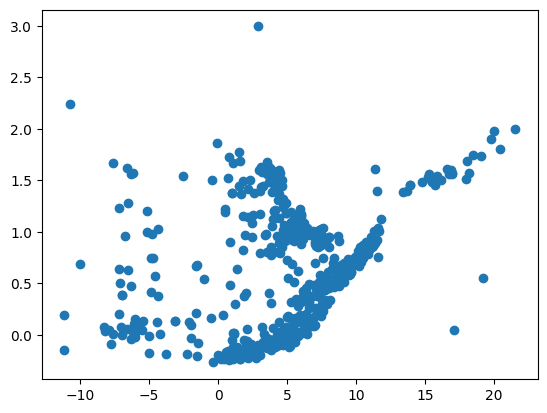

In [87]:
abs_mag = star_data['abs_mag']
ci = star_data['ci']
plt.scatter(abs_mag,ci)


**Task 5:**

a) Sort the DataFrame by the absolute magnitude.

b) Save the sorted DataFrame to a new CSV-formatted file.

In [88]:
# Task 5a)
star_data = star_data.sort_values(by = "abs_mag", ascending = False)
print(star_data)

         id             proper  con    mag         dist      spect     ci  \
446  118720           Wolf 359  Leo  13.45       2.3906         M6  2.000   
296   70666   Proxima Centauri  Cen  11.01       1.2959       M5Ve  1.807   
397  119518             EZ Aqr  Aqr  12.66       3.3979      M5  e  1.980   
23   119585           Ross 248  And  12.29       3.1686     dM6  e  1.900   
412    3820  Van Maanen's Star  Psc  12.37       4.2626         DG  0.554   
..      ...                ...  ...    ...          ...        ...    ...   
126   26159                NaN  Ori   6.71  100000.0000  B0.5Vp...  0.080   
27     6228                NaN  Cas   4.95  100000.0000       F0Ia  0.683   
423  106916        Garnet Star  Cep   4.23  100000.0000       M2Ia  2.242   
10    89064              Polis  Sgr   3.84  100000.0000     B2III:  0.195   
437   51475            Shaomin  Leo   3.84  100000.0000    B1Ib SB -0.148   

              lum             x             y             z    abs_mag  
44

The DataFrame is sorted by the calculated Absolute Magnitude ($M$). We use the Pandas function sort_values() on the column abs_mag. The sorting is done in descending order (ascending=False) to list the stars in order from the faintest (darkest) to the brightest (most luminous) stars.

In [89]:
#Task 5b)
star_data.to_csv("star_data_with_bmi.csv")

**References**:

[cite_start][1] The Pandas Development Team pandas-dev/pandas: Pandas Zenodo, 2020 ([https://pandas.pydata.org](https://pandas.pydata.org)) [cite: 68]

[2] Pandas user guide, [https://pandas.pydata.org/docs/user_guide/index.html#user-guide](https://pandas.pydata.org/docs/user_guide/index.html#user-guide). [cite_start]Online; accessed on May 8, 2024. [cite: 69]

[3] Hughes, D.W., 2006. The introduction of absolute magnitude (1902-1922). [cite_start]Journal of Astronomical History and Heritage, 9(2), 173-179. [cite: 70]

[cite_start][4] Pogson, N., 1856. Magnitudes of Thirty-six of the Minor Planets for the first day of each month of the year 1857. Monthly Notices of the Royal Astronomical Society, 17(1), 12-15. [cite: 71]

[5] Beech, M., 2008. The reluctant parsec and the overlooked light-year. The Observatory, 128, p. [cite_start]489-494. [cite: 72]

[6] AstroNexus (2025) HYG Star Database Archive. [online] Codeberg. Available at: [https://codeberg.org/astronexus/hyg](https://codeberg.org/astronexus/hyg). [cite_start]Online; accessed on Oct. 30, 2025. [cite: 73]

[7] DeVorkin, D.H., 1978. Steps toward the Hertzsprung-Russell diagram. [cite_start]Physics Today, 31(3), pp.32-39. [cite: 74]

[8] Python Software Foundation. Python Language Reference, version 3.12. Available at [http://www.python.org](http://www.python.org). [cite_start]Online; accessed on May 8, 2024. [cite: 75]

[cite_start][9] van Rossum, G. Python tutorial, Technical Report CS-R9526, Centrum voor Wiskunde en Informatica (CWI), Amsterdam, 1995. [cite: 76]